# International vs. Domestic Tourism Package Sales in Azerbaijan

## Project Overview

This project explores how tourism package sales in Azerbaijan have changed over time, focusing on domestic and international travel packages. Using official open data, the analysis identifies long-term trends, the impact of major events such as the COVID-19 pandemic, and possible future developments in the tourism market.

Data taken from the **Digital Azerbaijan** website.

## Business Questions

1. How have domestic and international tourism package sales changed over time?
2. Which years showed the strongest growth or decline?
3. How did the COVID-19 pandemic affect tourism package sales?
4. Which type of tourism recovered faster after the pandemic?
5. What are the expected sales trends for the next five years?

## Data Collection
In this section, the dataset is imported directly from Digital Azerbaijan’s Open Data API. The data is loaded into a pandas DataFrame for further processing and analysis.

In [62]:
import chardet
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np
from io import StringIO
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
url = "https://admin.opendata.az/api/3/action/package_show?id=value-of-tourism-envelopes-sold"

data = requests.get(url).json()

resources = data["result"]["resources"]
csv_url = resources[0]["url"]

# download CSV safely
response = requests.get(csv_url, verify=False)
csv_data = StringIO(response.text)

result = chardet.detect(response.content)
encoding = result['encoding']

print("Detected encoding:", encoding)

df = pd.read_csv(StringIO(response.content.decode(encoding)))
print(df.head())

Detected encoding: utf-8
   Year  Unnamed: 1  Satılmış turizm zərflərinin dəyəri (min manat)  \
0  2024         NaN                                        128675.6   
1  2023         NaN                                         26915.5   
2  2022         NaN                                         15915.2   
3  2021         NaN                                          5374.0   
4  2020         NaN                                          4988.4   

   Ölkə daxilində səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat)  \
0                                             2404.7                                                            
1                                             2098.0                                                            
2                                              803.3                                                            
3                                              467.1                                            

## Initial Dataset Inspection
After loading the data, the first step is to inspect its structure. This includes:

* Number of rows and columns
* Data types
* Missing values
* General statistical summary

This step helps identify potential issues before cleaning and modeling.

In [63]:
df.head()

,Year,Unnamed: 1,Satılmış turizm zərflərinin dəyəri (min manat),Ölkə daxilində səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat),Ölkədən kənarda səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat),Azərbaycan ərazisinə səyahət etmək üçün əcnəbilər və vətəndaşlığı olmayan şəxslərə satılmış turizm zərflərinin dəyəri (min manat),Qrup halında satılmış turizm zərflərinin dəyəri (min manat),Fərdi halda satılmış turizm zərflərinin dəyəri (min manat)
0,2024,NaN,128675.6,2404.7,117158.1,9112.8,18023.4,110652.2
1,2023,NaN,26915.5,2098.0,19889.8,4927.7,4766.4,22149.1
2,2022,NaN,15915.2,803.3,11206.6,3905.3,2224.2,13691.0
3,2021,NaN,5374.0,467.1,4639.1,267.8,828.0,4546.0
4,2020,NaN,4988.4,15.8,4162.4,810.2,716.8,4271.6


In [64]:
df.shape ##Shows the size of the dataset.

(24, 8)

In [65]:
df.info() ##Shows basic information about the dataframe.

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 8 columns):
 #   Column                                                                                                                             Non-Null Count  Dtype  
---  ------                                                                                                                             --------------  -----  
 0   Year                                                                                                                               24 non-null     int64  
 1   Unnamed: 1                                                                                                                         0 non-null      float64
 2   Satılmış turizm zərflərinin dəyəri (min manat)                                                                                     24 non-null     float64
 3   Ölkə daxilində səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min mana

In [66]:
df.describe() ##Shows statistical summary of numeric columns.

,Year,Unnamed: 1,Satılmış turizm zərflərinin dəyəri (min manat),Ölkə daxilində səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat),Ölkədən kənarda səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat),Azərbaycan ərazisinə səyahət etmək üçün əcnəbilər və vətəndaşlığı olmayan şəxslərə satılmış turizm zərflərinin dəyəri (min manat),Qrup halında satılmış turizm zərflərinin dəyəri (min manat),Fərdi halda satılmış turizm zərflərinin dəyəri (min manat)
count,24.000000,0.0,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,2012.500000,NaN,28433.270833,2221.670833,22344.258333,3867.345833,7711.312500,20697.016667
std,7.071068,NaN,30581.126369,2076.037412,25710.571454,4981.944825,7956.340163,24039.628367
min,2001.000000,NaN,198.600000,0.000000,198.600000,0.000000,0.000000,0.000000
25%,2006.750000,NaN,5277.600000,719.250000,4519.925000,265.500000,800.200000,4477.400000
50%,2012.500000,NaN,20881.950000,1983.450000,15894.950000,2142.500000,3798.000000,13795.150000
75%,2018.250000,NaN,41242.975000,2859.850000,34487.050000,4766.000000,12752.450000,27555.625000
max,2024.000000,NaN,128675.600000,7071.800000,117158.100000,20289.000000,27204.200000,110652.200000


In [67]:
df.isna().sum() ##Check missing values in each column

Year                                                                                                                                  0
Unnamed: 1                                                                                                                           24
Satılmış turizm zərflərinin dəyəri (min manat)                                                                                        0
Ölkə daxilində səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat)                            0
Ölkədən kənarda səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat)                           0
Azərbaycan ərazisinə səyahət etmək üçün əcnəbilər və vətəndaşlığı olmayan şəxslərə satılmış turizm zərflərinin dəyəri (min manat)     0
Qrup halında satılmış turizm zərflərinin dəyəri (min manat)                                                                           0
Fərdi halda satılmış turizm zərflərinin dəyəri (

## Column Renaming
The original Azerbaijani column names are translated into short English names. Also, the names need to be shortened.

In [68]:
df.rename(columns={
    "Ölkə daxilində səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat)": "Domestic",
    "Ölkədən kənarda səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat)": "International"
}, inplace=True)

# Convert to numeric (safety)
df["Domestic"] = pd.to_numeric(df["Domestic"], errors="coerce") / 1000
df["International"] = pd.to_numeric(df["International"], errors="coerce") / 1000

## Data Cleaning
The dataset is cleaned of missing values.

In [69]:
df.drop(columns=["Unnamed: 1"], errors="ignore", inplace=True) ##Delete empty column

In [70]:
df.head()

,Year,Satılmış turizm zərflərinin dəyəri (min manat),Domestic,International,Azərbaycan ərazisinə səyahət etmək üçün əcnəbilər və vətəndaşlığı olmayan şəxslərə satılmış turizm zərflərinin dəyəri (min manat),Qrup halında satılmış turizm zərflərinin dəyəri (min manat),Fərdi halda satılmış turizm zərflərinin dəyəri (min manat)
0,2024,128675.6,2.4047,117.1581,9112.8,18023.4,110652.2
1,2023,26915.5,2.0980,19.8898,4927.7,4766.4,22149.1
2,2022,15915.2,0.8033,11.2066,3905.3,2224.2,13691.0
3,2021,5374.0,0.4671,4.6391,267.8,828.0,4546.0
4,2020,4988.4,0.0158,4.1624,810.2,716.8,4271.6


## Exploratory Data Analysis
This section compares the historical development of domestic and international tourism package sales.

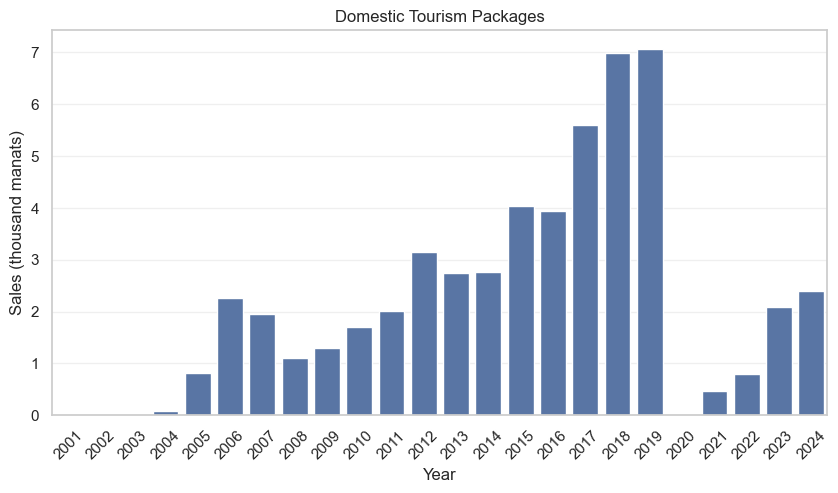

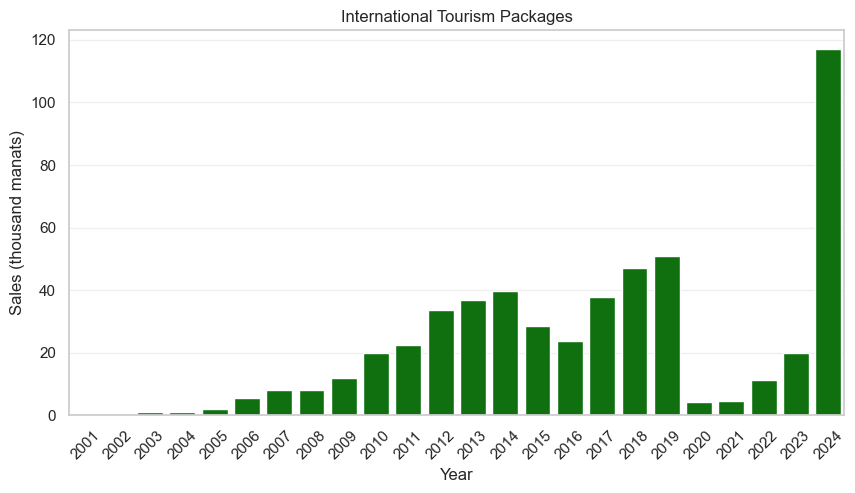

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Domestic
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Year", y="Domestic")
plt.title("Domestic Tourism Packages")
plt.xlabel("Year")
plt.ylabel("Sales (thousand manats)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# International
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Year", y="International", color="green")
plt.title("International Tourism Packages")
plt.xlabel("Year")
plt.ylabel("Sales (thousand manats)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

Package tour sales began to grow nonlinearly from 2004 (Domestic) and from 2003 (International), but fell sharply in 2020. In domestic countries, international sales increased sharply in 2024.

## Impact of COVID-19
The COVID-19 period is analyzed separately to understand its effect on tourism package sales.

In [72]:
# Covid indicator
df["Covid"] = df["Year"].isin([2020, 2021, 2022]).astype(int)

# Center year
year_mean = df["Year"].mean()
df["Year_centered"] = df["Year"] - year_mean
features = ["Year_centered", "Covid"]

Covid feature: tells the model that 2020–2022 were unusual years, so it doesn’t treat those sales patterns as normal.

Year_centered: makes the time variable easier for the model to learn (better stability and interpretation).

In [73]:
# -------------------------
# INTERNATIONAL
# -------------------------
df_filtered_int = df[df["Year"] != 2024].copy()

x_int = df_filtered_int[features]
y_int = df_filtered_int["International"]

# -------------------------
# DOMESTIC
# -------------------------
df_dom_filtered = df[df["Year"] >= 2010]

x_dom = df_dom_filtered[features]
y_dom = df_dom_filtered["Domestic"]

# -------------------------
# TRAIN MODELS
# -------------------------
lr_int = LinearRegression()
lr_dom = LinearRegression()

lr_int.fit(x_int, y_int)
lr_dom.fit(x_dom, y_dom)

dt_int = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_dom = DecisionTreeRegressor(max_depth=5, random_state=42)

dt_int.fit(x_int, y_int)
dt_dom.fit(x_dom, y_dom)

rf_int = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_dom = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

rf_int.fit(x_int, y_int)
rf_dom.fit(x_dom, y_dom)

# -------------------------
# SPLIT (IMPORTANT FIX HERE)
# -------------------------

# INTERNATIONAL
train_mask_int = df_filtered_int["Year"] < 2022
test_mask_int  = df_filtered_int["Year"] >= 2022

x_train_int = x_int[train_mask_int]
x_test_int  = x_int[test_mask_int]

y_train_int = y_int[train_mask_int]
y_test_int  = y_int[test_mask_int]

# DOMESTIC (USE FILTERED HERE TOO)
train_mask_dom = df_dom_filtered["Year"] < 2022
test_mask_dom  = df_dom_filtered["Year"] >= 2022

x_train_dom = x_dom[train_mask_dom]
x_test_dom  = x_dom[test_mask_dom]

y_train_dom = y_dom[train_mask_dom]
y_test_dom  = y_dom[test_mask_dom]

This code builds and evaluates separate forecasting models for International and Domestic sales.

* Data filtering
  * International: excludes 2024 because it behaves like an outlier
  * Domestic: uses data from 2010 onward
* Feature & target setup
  * x_* → input features (Year_centered, COVID)
  * y_* → target sales (International or Domestic)
* Model training
Three models are trained for each segment:
  * Linear Regression → captures overall trend
  * Decision Tree → captures nonlinear patterns
  * Random Forest → improves accuracy using multiple trees
* Train/test split (time-based)
  * Train: years before 2022
  * Test: 2022 and after
(keeps chronological order → important for forecasting)

## Growth Rate Analysis
Growth rates are calculated to identify periods of rapid increase or decline.Growth rate

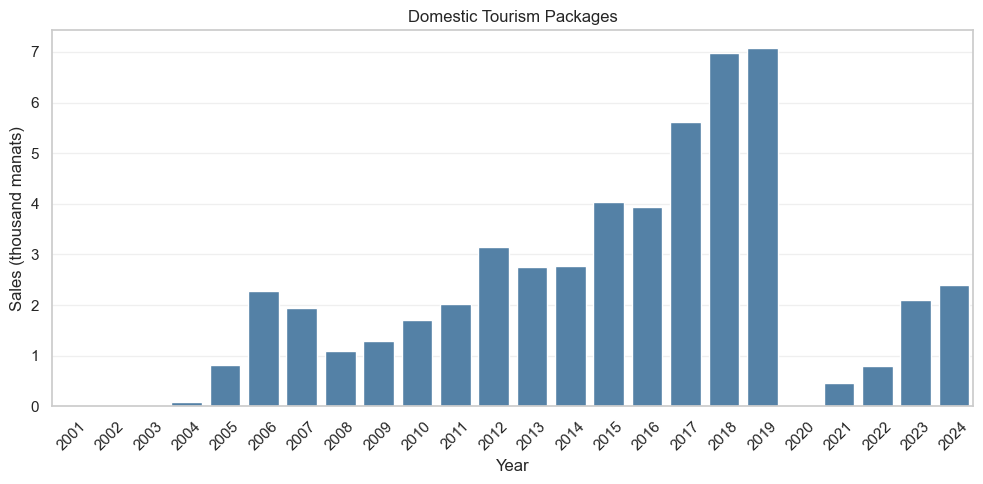

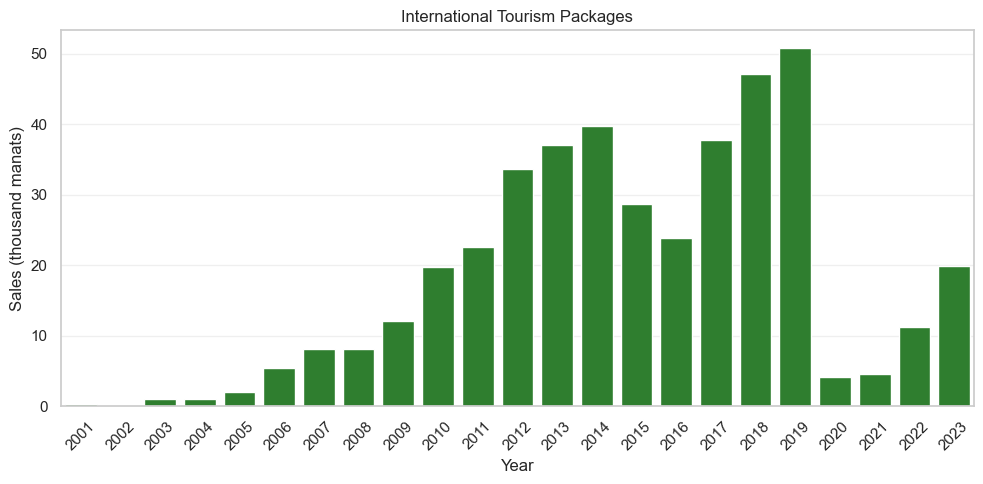

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure style
sns.set(style="whitegrid")

# --- Domestic Plot ---
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Year",
    y="Domestic",
    color="steelblue"
)

plt.title("Domestic Tourism Packages")
plt.xlabel("Year")
plt.ylabel("Sales (thousand manats)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# --- International Plot ---
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_filtered_int,
    x="Year",
    y="International",
    color="forestgreen"
)

plt.title("International Tourism Packages")
plt.xlabel("Year")
plt.ylabel("Sales (thousand manats)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [75]:
# Correct initialization
lr_int = LinearRegression()
dt_int = DecisionTreeRegressor(random_state=42);
rf_int = RandomForestRegressor(random_state=42);

lr_dom = LinearRegression();
dt_dom = DecisionTreeRegressor(random_state=42);
rf_dom = RandomForestRegressor(random_state=42);
# Train models
lr_int.fit(x_train_int, y_train_int);
dt_int.fit(x_train_int, y_train_int);
rf_int.fit(x_train_int, y_train_int);
lr_dom.fit(x_train_dom, y_train_dom);
dt_dom.fit(x_train_dom, y_train_dom);
rf_dom.fit(x_train_dom, y_train_dom);

In [76]:
lr_pred_int = lr_int.predict(x_test_int)
dt_pred_int = dt_int.predict(x_test_int)
rf_pred_int = rf_int.predict(x_test_int)

lr_pred_dom = lr_dom.predict(x_test_dom)
dt_pred_dom = dt_dom.predict(x_test_dom)
rf_pred_dom = rf_dom.predict(x_test_dom)

In [77]:
results_int = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_int, lr_pred_int)),
        np.sqrt(mean_squared_error(y_test_int, dt_pred_int)),
        np.sqrt(mean_squared_error(y_test_int, rf_pred_int))
    ],
    "MAE": [
        mean_absolute_error(y_test_int, lr_pred_int),
        mean_absolute_error(y_test_int, dt_pred_int),
        mean_absolute_error(y_test_int, rf_pred_int)
    ]
})

print("International Results:")
print(results_int)

International Results:
               Model       RMSE        MAE
0  Linear Regression  26.549188  19.977265
1      Decision Tree  11.741293  10.909100
2      Random Forest   6.521700   5.867235


## Model Evaluation
The models are evaluated to determine which forecasting approach is the most accurate.

In [78]:
results_dom = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_dom, lr_pred_dom)),
        np.sqrt(mean_squared_error(y_test_dom, dt_pred_dom)),
        np.sqrt(mean_squared_error(y_test_dom, rf_pred_dom))
    ]
})

print("Domestic Results:")
print(results_dom)

Domestic Results:
               Model      RMSE
0  Linear Regression  5.885798
1      Decision Tree  1.475032
2      Random Forest  1.642638


## Visualization of Model Performance
Model performance is visualized to compare forecasting accuracy.

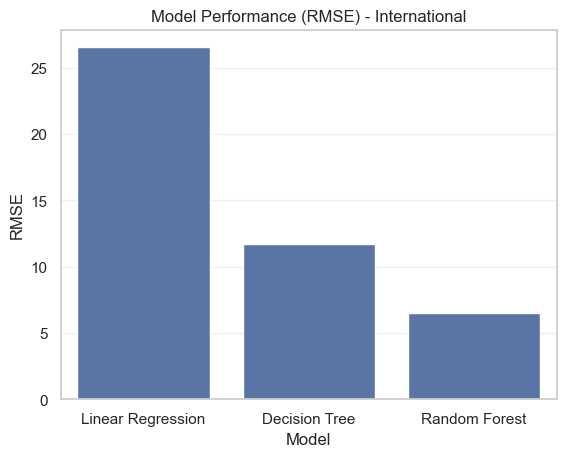

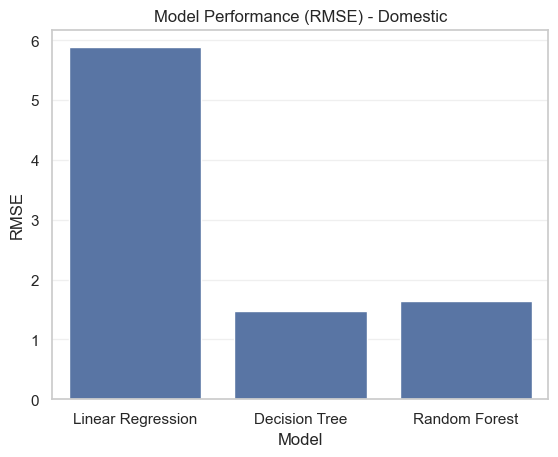

In [ ]:
sns.barplot(data=results_int, x="Model", y="RMSE")

plt.title("Model Performance (RMSE) - International")
plt.ylabel("RMSE")
plt.grid(axis='y', alpha=0.3) 

plt.show()
sns.barplot(data=results_dom, x="Model", y="RMSE")

plt.title("Model Performance (RMSE) - Domestic")
plt.ylabel("RMSE")
plt.grid(axis='y', alpha=0.3)

plt.show()

The evaluation shows that Random Forest and Decision Tree models perform better than Linear Regression, especially for International sales, where Linear Regression has the highest error (RMSE). For Domestic sales, all models perform well, but Decision Tree gives the lowest error.

Even though Linear Regression is not the most accurate, it is still used in the final forecast because it captures the overall long-term trend clearly and smoothly, which is important for time-series forecasting stability.

## Future Predictions

In [80]:
future = pd.DataFrame({"Year": range(2025, 2030)})

future["Covid"] = 0
future["Year_centered"] = future["Year"] - year_mean

x_future = future[features]

### Future Tourism Forecasts (2023–2027)
The selected model is used to estimate future domestic and international tourism package sales.

In [81]:
# --- Individual model predictions (KEEP)
future["Domestic_LR"] = lr_dom.predict(x_future)
future["Domestic_DT"] = dt_dom.predict(x_future)
future["Domestic_RF"] = rf_dom.predict(x_future)

future["International_LR"] = lr_int.predict(x_future)
future["International_DT"] = dt_int.predict(x_future)
future["International_RF"] = rf_int.predict(x_future)

In [82]:

future["Domestic_Forecast"] = (
    0.8 * future["Domestic_DT"] +
    0.2 * future["Domestic_LR"]
)

# International → DT + LR
future["International_Forecast"] = (
    0.7 * future["International_DT"] +
    0.3 * future["International_LR"]
)

The final predictions are created using a weighted combination of models:

* Domestic: 80% Decision Tree + 20% Linear Regression
* International: 70% Decision Tree + 30% Linear Regression

This blending improves stability and reduces the risk of overfitting from a single model.

In [83]:
pred_df = future[[
    "Year",
    "Domestic_Forecast",
    "International_Forecast"
]]

print(pred_df)

   Year  Domestic_Forecast  International_Forecast
0  2025           2.446265               22.179285
1  2026           2.567425               23.042248
2  2027           2.688586               23.905212
3  2028           2.809746               24.768175
4  2029           2.930906               25.631138


### Forecast Visualization
Historical and predicted values are displayed together to show long-term trends.

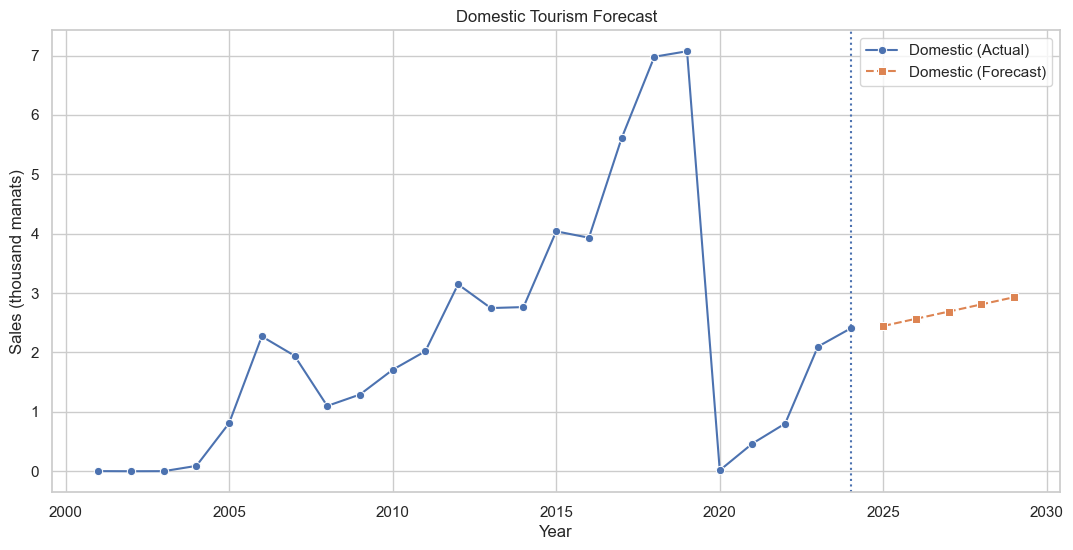

In [84]:
# Domestic
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=df,
    x="Year",
    y="Domestic",
    marker="o",
    label="Domestic (Actual)"
)

sns.lineplot(
    data=pred_df,
    x="Year",
    y="Domestic_Forecast",
    marker="s",
    linestyle="--",
    label="Domestic (Forecast)"
)

plt.axvline(x=2024, linestyle=":", linewidth=1.5)

plt.title("Domestic Tourism Forecast")
plt.xlabel("Year")
plt.ylabel("Sales (thousand manats)")
plt.legend()
plt.show()

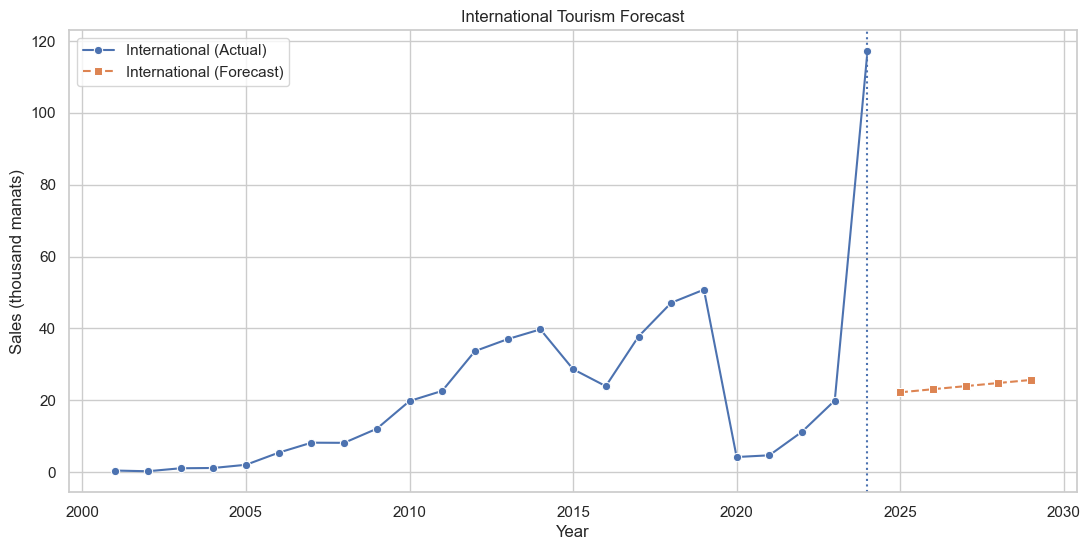

In [85]:
# International
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=df,
    x="Year",
    y="International",
    marker="o",
    label="International (Actual)"
)

sns.lineplot(
    data=pred_df,
    x="Year",
    y="International_Forecast",
    marker="s",
    linestyle="--",
    label="International (Forecast)"
)

plt.axvline(x=2024, linestyle=":", linewidth=1.5)

plt.title("International Tourism Forecast")
plt.xlabel("Year")
plt.ylabel("Sales (thousand manats)")
plt.legend()
plt.show()

## Answers to the questions
1. How have domestic and international tourism package sales changed over time?
 * In 2001–2004, sales for both segments were very low.
 * From 2004 to 2019, domestic sales gradually increased and showed steady growth.
 * International sales started to rise from 2003 and continued growing until 2019.
 * During 2020–2022, both segments declined due to the pandemic.
 * In 2023–2024, domestic tourism strongly recovered, while international tourism also started to grow again, although more slowly.
2. Which years showed the strongest increase or decrease?
 * The sharpest decline occurred in 2020 and 2021, especially in international sales.
 * Domestic sales also dropped in 2020, but the decline was less severe.
 * The strongest growth was observed in 2023–2024, particularly in domestic tourism, with international sales also increasing in 2024.
3. How did the COVID-19 pandemic affect tourism package sales?
 * The pandemic caused a significant decline during 2020–2022.
 * International tourism was affected the most due to border closures and travel restrictions.
 * Domestic tourism proved more resilient, although it also decreased in the early pandemic years.
4. Which type of tourism recovered faster after the pandemic?
 * Domestic tourism recovered faster.
 * In 2023–2024, domestic sales grew more rapidly and returned to pre-pandemic levels sooner.
 * International tourism began recovering as well, but more slowly and was not fully restored by 2024.
5. What are the expected sales trends for the next five years?
 * Model forecasts suggest continued growth in both domestic and international sales from 2025–2029.
 * Domestic tourism is expected to show more stable and consistent growth.
 * International tourism is also expected to grow, but with more variability and dependence on global travel trends.
 * Overall trend: gradual post-pandemic recovery followed by continued growth.

Note: These answers are based on current data and a forecasting model. Real outcomes may vary depending on geopolitical, economic, and health-related factors.

## Final Conclusion
Domestic tourism remained more resilient during the pandemic, while international tourism experienced stronger declines but recovered steadily afterward.